In [1]:
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from agents.hotel.agent import hotel_graph as graph

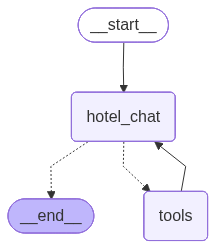

In [2]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [2]:
def stream_graph_updates(inputs: dict):
    for event in graph.stream(inputs):
        if "hotel_chat" in event:
            messages = event["hotel_chat"].get("messages", [])
            for msg in messages:
                # Nếu là AIMessage (object)
                if hasattr(msg, "content") and msg.content:
                    print("Assistant:", msg.content)
                # Nếu là dict
                elif isinstance(msg, dict) and msg.get("role") == "assistant":
                    print("Assistant:", msg.get("content"))
        if "tools" in event:
            messages = event["tools"].get("messages", [])
            for msg in messages:
                if hasattr(msg, "content") and msg.content:
                    print("Tool Output:", msg.content)
                elif isinstance(msg, dict):
                    print("Tool Output:", msg.get("content"))


In [7]:
test_cases = [
    "Tìm kiếm khách sạn tốt nhất Hà Nội.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tìm kiếm khách sạn tốt nhất Hà Nội.
{'messages': [{'role': 'user', 'content': 'Tìm kiếm khách sạn tốt nhất Hà Nội.'}]}
 Qdrant semantic search: Found 3 results
Tool Output: [{"id": 3, "name": "La Siesta Classic Ma May", "location": "Hà Nội", "price_tier": "Upper Midscale", "rating": 8.7}, {"id": 1, "name": "Sofitel Legend Metropole Hanoi", "location": "Hà Nội", "price_tier": "Luxury", "rating": 9.2}, {"id": 2, "name": "Lotte Hotel Hanoi", "location": "Hà Nội", "price_tier": "Upper Upscale", "rating": 9}]
Assistant: Khách sạn tốt nhất Hà Nội là:

*   **Sofitel Legend Metropole Hanoi**: Xếp hạng 9.2, phân khúc Giá: Luxury
*   **Lotte Hotel Hanoi**: Xếp hạng 9, phân khúc Giá: Upper Upscale
*   **La Siesta Classic Ma May**: Xếp hạng 8.7, phân khúc Giá: Upper Midscale


In [4]:
test_cases = [
    "Tìm kiếm khách sạn ở Hà Nội.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)



🧑‍💻 User: Tìm kiếm khách sạn ở Hàà Nội.
{'messages': [{'role': 'user', 'content': 'Tìm kiếm khách sạn ở Hàà Nội.'}]}
 Qdrant semantic search: Found 3 results
Tool Output: [{"id": 3, "name": "La Siesta Classic Ma May", "location": "Hà Nội", "price_tier": "Upper Midscale", "rating": 8.7}, {"id": 1, "name": "Sofitel Legend Metropole Hanoi", "location": "Hà Nội", "price_tier": "Luxury", "rating": 9.2}, {"id": 2, "name": "Lotte Hotel Hanoi", "location": "Hà Nội", "price_tier": "Upper Upscale", "rating": 9}]
Assistant: Tôi tìm thấy 3 khách sạn ở Hà Nội:

*   **La Siesta Classic Ma May**: Xếp hạng 8.7, phân khúc giá cận cao cấp.
*   **Sofitel Legend Metropole Hanoi**: Xếp hạng 9.2, phân khúc giá sang trọng.
*   **Lotte Hotel Hanoi**: Xếp hạng 9, phân khúc giá cao cấp.

Bạn muốn tìm hiểu thêm về khách sạn nào?


In [7]:
test_cases = [
    "Tìm kiếm khách sạn ở Đà Nẵng, rating cỡ 9.0, gia ca hạng sang. ",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tìm kiếm khách sạn ở Đà Nẵng, rating cỡ 9.0, gia ca hạng sang. 
{'messages': [{'role': 'user', 'content': 'Tìm kiếm khách sạn ở Đà Nẵng, rating cỡ 9.0, gia ca hạng sang. '}]}
 Qdrant semantic search: Found 1 results
Tool Output: [{"id": 7, "name": "InterContinental Danang Sun Peninsula", "location": "Đà Nẵng", "price_tier": "Luxury", "rating": 9.3}]
Assistant: Khách sạn InterContinental Danang Sun Peninsula ở Đà Nẵng có rating 9.3 và là hạng sang. Bạn có muốn đặt phòng ở đây không?


In [5]:
test_cases = [
    "Tôi muốn kiếm phòng ở khách sạn Sofitel Hanoi, có sức chứa 2 người.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)



🧑‍💻 User: Tôi muốn kiếm phòng ở khách sạn Sofitel Hanoi, có sức chứa 2 người.
{'messages': [{'role': 'user', 'content': 'Tôi muốn kiếm phòng ở khách sạn Sofitel Hanoi, có sức chứa 2 người.'}]}
Tool Output: [{"room_id": 11, "hotel_id": 4, "room_type": "Suite", "capacity": 2, "price": 9500000}, {"room_id": 12, "hotel_id": 4, "room_type": "Family Villa", "capacity": 4, "price": 12000000}, {"room_id": 10, "hotel_id": 4, "room_type": "Deluxe Room", "capacity": 2, "price": 7000000}]
Assistant: Khách sạn Sofitel Hanoi có các loại phòng sau cho 2 người:

*   **Suite:** Sức chứa 2 người, giá 9.500.000 VNĐ.
*   **Deluxe Room:** Sức chứa 2 người, giá 7.000.000 VNĐ.

Bạn muốn đặt loại phòng nào?


In [ ]:
test_cases = [
    "Tôi muốn kiếm phòng ở khách sạn Sofitel Legend Metropole Hanoi, có sức chứa 2 người, giá cả dưới 8 triệu.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn kiếm phòng ở khách sạn Sofitel Legend Metropole Hanoi, có sức chứa 2 người, giá cả dưới 8 triệu.
{'messages': [{'role': 'user', 'content': 'Tôi muốn kiếm phòng ở khách sạn Sofitel Legend Metropole Hanoi, có sức chứa 2 người, giá cả dưới 8 triệu.'}]}
Collection 'hotels' already exists. Skipping creation.
Found 21 existing points in Qdrant.
 Qdrant is up-to-date. No new hotels to index.
 Exact search (rooms): Found 1 results
Tool Output: [{"room_id": 1, "hotel_id": 1, "room_type": "Deluxe Room", "capacity": 2, "price": 7000000}]
Assistant: Khách sạn Sofitel Legend Metropole Hanoi có phòng Deluxe Room với sức chứa 2 người, giá 7 triệu đồng. Bạn có muốn đặt phòng này không?


In [ ]:
test_cases = [
    "Tôi muốn kiếm phòng ở khách sạn Sofitel  Hanoi, có sức chứa 2 người, giá cả ít nhất 8 triệu.",
]
for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn kiếm phòng ở khách sạn Sofitel  Hanoi, có sức chứa 2 người, giá cả ít nhất 8 triệu.
{'messages': [{'role': 'user', 'content': 'Tôi muốn kiếm phòng ở khách sạn Sofitel  Hanoi, có sức chứa 2 người, giá cả ít nhất 8 triệu.'}]}
Tool Output: [{"room_id": 11, "hotel_id": 4, "room_type": "Suite", "capacity": 2, "price": 9500000}, {"room_id": 12, "hotel_id": 4, "room_type": "Family Villa", "capacity": 4, "price": 12000000}]
Assistant: Khách sạn Sofitel Hanoi có phòng Suite với sức chứa 2 người, giá 9.500.000 VNĐ. Ngoài ra còn có phòng Family Villa với sức chứa 4 người, giá 12.000.000 VNĐ. Bạn muốn đặt phòng nào?


In [3]:
test_cases = [
    "Tôi muốn đặt phòng khách sạn scs , dạng phòng Family Villa , từ ngày 15/11/2025 đến 16/11/2025 ",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng khách sạn scs , dạng phòng Family Villa , từ ngày 15/11/2025 đến 16/11/2025 
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng khách sạn scs , dạng phòng Family Villa , từ ngày 15/11/2025 đến 16/11/2025 '}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 8 existing booking points in Qdrant.
⏳ Indexing 8 bookings...
 Successfully indexed 8 bookings to Qdrant.
Tool Output: Không tìm thấy phòng 'Family Villa' tại khách sạn 'scs'.
Assistant: Tôi không tìm thấy phòng 'Family Villa' tại khách sạn 'scs'. Bạn có muốn thử một loại phòng khác không?


In [6]:
test_cases = [
    "Tôi muốn đặt phòng khách sạn jkbeauty , dạng phòng Family Villa , từ ngày 15/11/2025 đến 16/11/2025 ",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng khách sạn jkbeauty , dạng phòng Family Villa , từ ngày 15/11/2025 đến 16/11/2025 
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng khách sạn jkbeauty , dạng phòng Family Villa , từ ngày 15/11/2025 đến 16/11/2025 '}]}
Tool Output: Không tìm thấy phòng 'Family Villa' tại khách sạn 'jkbeauty'.
Assistant: Tôi không tìm thấy phòng 'Family Villa' tại khách sạn 'jkbeauty'. Bạn có muốn thử tìm loại phòng khác không?


In [ ]:
test_cases = [
    "Tôi muốn đặt phòng khách sạn Sofitel Legend Metropole, dạng phòng Family Villa , từ ngày 15/11/2025 đến 16/11/2025 ",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng khách sạn Sofitel Legend Metropole, dạng phòng Family Villa , từ ngày 15/11/2025 đến 16/11/2025 
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng khách sạn Sofitel Legend Metropole, dạng phòng Family Villa , từ ngày 15/11/2025 đến 16/11/2025 '}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Tool Output: Đặt phòng thành công! Mã đặt phòng của bạn là 1. Tổng chi phí là 12,000,000 VNĐ.
Assistant: B

In [ ]:
test_cases = [
    "Tôi muốn đặt phòng khách sạn Sofitel Legend Metropole, dạng phòng Deluxe, từ ngày 15/11/2025 đến 16/11/2025 ",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng khách sạn Sofitel Legend Metropole, dạng phòng Deluxe, từ ngày 15/11/2025 đến 16/11/2025 
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng khách sạn Sofitel Legend Metropole, dạng phòng Deluxe, từ ngày 15/11/2025 đến 16/11/2025 '}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Tool Output: Đặt phòng thành công! Mã đặt phòng của bạn là 2. Tổng chi phí là 7,000,000 VNĐ.
Assistant: Bạn đã đặt phòng

In [4]:
test_cases = [
    "Tôi muốn đặt phòng khách sạn InterContinental, dạng phòng Deluxe, từ ngày 15/11/2025 đến 16/11/2025 ",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng khách sạn InterContinental, dạng phòng Deluxe, từ ngày 15/11/2025 đến 16/11/2025 
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng khách sạn InterContinental, dạng phòng Deluxe, từ ngày 15/11/2025 đến 16/11/2025 '}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 7 existing booking points in Qdrant.
⏳ Indexing 8 bookings...
 Successfully indexed 8 bookings to Qdrant.
Tool Output: Đặt phòng thành công! Mã đặt phòng của bạn là 8. Tổng chi phí là 7,000,000 VNĐ.
Assistant: Bạn đã đặt phòng thành công! Mã đặt phòng của bạn là 8. Tổng chi phí là 7,000,000 VNĐ.


In [ ]:
test_cases = [
    "Tôi muốn muốn cập nhập booking id 2 check in 22/12/2025 check out 23/12/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn muốn cập nhập booking id 2 check in 22/12/2025 check out 23/12/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn muốn cập nhập booking id 2 check in 22/12/2025 check out 23/12/2025.'}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 4 existing booking points in Qdrant.
⏳ Indexing 4 bookings...
 Successfully indexed 4 bookings to Qdrant.
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant

In [ ]:
test_cases = [
    "Tôi muốn đặt phòng standard ở La Siesta từ ngày 13/11/2025 đến 16/11/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng standard ở La Siesta từ ngày 13/11/2025 đến 16/11/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng standard ở La Siesta từ ngày 13/11/2025 đến 16/11/2025.'}]}
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 2 existing booking points in Qdrant.
 Qdrant (Bookings) is up-to-date. No new bookings to index.
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 2 existing booking points in Qdrant.
⏳ Found 1 new bookings to index...
 Successfully indexed 1 new bookings to Qdrant.
Tool 

In [ ]:
test_cases = [
    "Tôi muốn đặt phòng standard ở La Siesta từ ngày 15/11/2025 đến 16/11/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng standard ở La Siesta từ ngày 15/11/2025 đến 16/11/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng standard ở La Siesta từ ngày 15/11/2025 đến 16/11/2025.'}]}
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 3 existing booking points in Qdrant.
 Qdrant (Bookings) is up-to-date. No new bookings to index.
Tool Output: Phòng 'standard' tại khách sạn 'La Siesta' đã được đặt trong khoảng thời gian '2025-11-15' - '2025-11-16'.
Assistant: Phòng 'standard' tại khách sạn 'La Siesta' đã được đặt trong khoảng thời gian '2025-11-15' - '2025-11-16'.


In [ ]:
test_cases = [
    "Tôi muốn đặt phòng standard ở La Siesta từ ngày 16/11/2025 đến 17/11/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng standard ở La Siesta từ ngày 16/11/2025 đến 17/11/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng standard ở La Siesta từ ngày 16/11/2025 đến 17/11/2025.'}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 3 existing booking points in Qdrant.
⏳ Found 1 new bookings to index...
 Successfully indexed 1 new bookings to Qdrant.
Tool Output: Đặt phòng thành công! Mã đặt phòng của bạn là 4. Tổng chi phí là 1,500,000 VNĐ.
Assistant: Bạn đã đặt phòng standard tại La Siesta thành công từ ngày 16/11/2025 đến 17/11/2025. Mã đặt phòng của bạn là 4. Tổng chi phí là 1,500,000 VNĐ.


In [ ]:
test_cases = [
    "Tôi muốn cập nhập booking id 3 là từ ngày 16/11/2025 đến 17/11/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn cập nhập booking id 3 là từ ngày 16/11/2025 đến 17/11/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn cập nhập booking id 3 là từ ngày 16/11/2025 đến 17/11/2025.'}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 4 existing booking points in Qdrant.
⏳ Indexing 4 bookings...
 Successfully indexed 4 bookings to Qdrant.
Tool Output: Phòng đã được đặt trong khoảng thời gian '16/11/2025' - '17/11/2025'.
Assistant: Phòng đã được đặt trong khoảng thời gian '16/11/2025' - '17/11/2025'.


In [3]:
test_cases = [
    "Tôi muốn hủy booking id 3.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn hủy booking id 3.
{'messages': [{'role': 'user', 'content': 'Tôi muốn hủy booking id 3.'}]}
Using qrant: 
Tool Output: Không thể hủy mã đặt phòng 3 vì đã bị hủy.
Assistant: Không thể hủy mã đặt phòng 3 vì đã bị hủy.


In [ ]:
test_cases = [
    "Tôi muốn cập nhập booking id 3 từ ngày 1/1/2026 đến 2/1/2026.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn cập nhập booking id 3 từ ngày 1/1/2026 đến 2/1/2026.
{'messages': [{'role': 'user', 'content': 'Tôi muốn cập nhập booking id 3 từ ngày 1/1/2026 đến 2/1/2026.'}]}
Tool Output: Không thể cập nhật mã đặt phòng 3 vì đã bị hủy.
Assistant: Tôi không thể cập nhật mã đặt phòng 3 vì nó đã bị hủy.


In [ ]:
test_cases = [
    "Tôi muốn cập nhập booking id 4 check in 13/11/2025 check out 16/11/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn cập nhập booking id 4 check in 13/11/2025 check out 16/11/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn cập nhập booking id 4 check in 13/11/2025 check out 16/11/2025.'}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 4 existing booking points in Qdrant.
⏳ Indexing 4 bookings...
 Successfully indexed 4 bookings to Qdrant.
Tool Output: Phòng đã được đặt trong khoảng thời gian '13/11/2025' - '16/11/2025'.
Assistant: Phòng đã được đặt trong khoảng thời gian '13/11/2025' - '16/11/2025'.


In [ ]:
test_cases = [
    "Tôi muốn hủy booking id 1.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn hủy booking id 1.
{'messages': [{'role': 'user', 'content': 'Tôi muốn hủy booking id 1.'}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 4 existing booking points in Qdrant.
⏳ Indexing 4 bookings...
 Successfully indexed 4 bookings to Qdrant.
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 4 existing booking points in Qdrant.
⏳ I

In [ ]:
test_cases = [
    "Tôi muốn cập nhập booking id 1 check in 13/11/2025 check out 16/11/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn cập nhập booking id 1 check in 13/11/2025 check out 16/11/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn cập nhập booking id 1 check in 13/11/2025 check out 16/11/2025.'}]}
Tool Output: Không thể cập nhật mã đặt phòng 1 vì đã bị hủy.
Assistant: Tôi không thể cập nhật mã đặt phòng 1 vì nó đã bị hủy.


In [ ]:
test_cases = [
    "Tôi muốn cập nhập booking id 4 check in 13/11/2025 check out 16/11/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn cập nhập booking id 4 check in 13/11/2025 check out 16/11/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn cập nhập booking id 4 check in 13/11/2025 check out 16/11/2025.'}]}
Tool Output: Không thể cập nhật mã đặt phòng 4 vì đã bị hủy.
Assistant: Tôi không thể cập nhật mã đặt phòng 4 vì nó đã bị hủy.


In [ ]:
test_cases = [
    "Tôi muốn đặt phòng standard ở La Siesta từ ngày 5/12/2025 đến 6/12/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng standard ở La Siesta từ ngày 5/12/2025 đến 6/12/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng standard ở La Siesta từ ngày 5/12/2025 đến 6/12/2025.'}]}
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 4 existing booking points in Qdrant.
⏳ Indexing 4 bookings...
 Successfully indexed 4 bookings to Qdrant.
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 4 existing booking points in Qdrant.
⏳ Indexing 5 bookings...
 Successfully indexed 5 bookings to Qdrant.
Tool Output: Đ

In [ ]:
test_cases = [
    "Tôi muốn đặt phòng standard ở La Siesta từ ngày 17/12/2025 đến 19/12/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng standard ở La Siesta từ ngày 17/12/2025 đến 19/12/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng standard ở La Siesta từ ngày 17/12/2025 đến 19/12/2025.'}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 5 existing booking points in Qdrant.
⏳ Indexing 5 bookings...
 Successfully indexed 5 bookings to Qdrant.
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdr

In [ ]:
test_cases = [
    "Tôi muốn hủy booking id 6.",
    "Tôi cập nhập booking id 6 check in 17/12/2025 check out 19/12/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn hủy booking id 6.
{'messages': [{'role': 'user', 'content': 'Tôi muốn hủy booking id 6.'}]}
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 6 existing booking points in Qdrant.
⏳ Indexing 6 bookings...
 Successfully indexed 6 bookings to Qdrant.
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 6 existing booking points in Qdrant.
⏳ Indexing 6 bookings...
 Successfully indexed 6 bookings to Qdrant.
Tool Output: Đã hủy thành công mã đặt phòng 6.
Assistant: Bạn đã hủy thành công mã đặt phòng 6.

🧑‍💻 User:

In [ ]:
test_cases = [
    "Tôi muốn đặt phòng standard ở La Siesta từ ngày 24/12/2025 đến 28/12/2025.",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng standard ở La Siesta từ ngày 24/12/2025 đến 28/12/2025.
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng standard ở La Siesta từ ngày 24/12/2025 đến 28/12/2025.'}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 6 existing booking points in Qdrant.
⏳ Indexing 6 bookings...
 Successfully indexed 6 bookings to Qdrant.
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdr

In [4]:
test_cases = [
    "Tôi muốn đặt phòng delux từ 1/1/2026 đến 3/1/2026 ở khách sạn InterContinental Danang",
]

for q in test_cases:
    print(f"\n🧑‍💻 User: {q}")
    inputs = {"messages": [{"role": "user", "content": q}]}
    print(inputs)
    stream_graph_updates(inputs)


🧑‍💻 User: Tôi muốn đặt phòng delux từ 1/1/2026 đến 3/1/2026 ở khách sạn InterContinental Danang
{'messages': [{'role': 'user', 'content': 'Tôi muốn đặt phòng delux từ 1/1/2026 đến 3/1/2026 ở khách sạn InterContinental Danang'}]}
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room points in Qdrant.
 Qdrant (Rooms) is up-to-date. No new rooms to index.
Found 9 existing booking points in Qdrant.
⏳ Indexing 8 bookings...
 Successfully indexed 8 bookings to Qdrant.
Collection 'hotels' already exists. Skipping creation.
Collection 'rooms' already exists. Skipping creation.
Collection 'hotel_bookings' already exists. Skipping creation.
Found 21 existing hotel points in Qdrant.
 Qdrant (Hotels) is up-to-date. No new hotels to index.
Found 63 existing room 